# 📊 Credit Risk & Customer Financial Health Analytics
### 🏢 FinTrust Digital Finance | Capstone Project
**Module:** ITS 2122 — Python for Data Science & AI  
**Intake:** HDSE 74

---

## 🛠️ Phase 1: Data Sanitation and Preprocessing
The objective of this phase is to load the raw financial portfolio dataset, audit its structure, handle anomalies, map categorical codes to readable labels, and engineer behavioral risk features.

In [53]:
import pandas as pd

### 🔍 Step 1 - Initial Data Assessment & Audit Findings
Based on the execution of data info and description, we observe the following:
* **Dataset Dimensions:** The data contains exactly 30,000 customer records and 25 attributes.
* **Data Type Realignment:** By passing `header=1` during ingestion, the structural shifted rows were resolved. All columns are now numeric (`int64`).
* **Missing Values:** No explicitly missing (`NaN`) values are detected across the rows.

In [54]:
df = pd.read_csv('default of credit card clients.csv', header=1) 
print("--- Data Loaded Successfully! ---")
print(f"Dataset Dimensions: {df.shape[0]} rows, {df.shape[1]} columns\n")
# print(df)

--- Data Loaded Successfully! ---
Dataset Dimensions: 30000 rows, 25 columns



### Step 2 - Initial Assessment

Display the data types and column structural summary

In [55]:
print("--- Dataset Information ---")
print(df.info())

--- Dataset Information ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 25 columns):
 #   Column                      Non-Null Count  Dtype
---  ------                      --------------  -----
 0   ID                          30000 non-null  int64
 1   LIMIT_BAL                   30000 non-null  int64
 2   SEX                         30000 non-null  int64
 3   EDUCATION                   30000 non-null  int64
 4   MARRIAGE                    30000 non-null  int64
 5   AGE                         30000 non-null  int64
 6   PAY_1                       30000 non-null  int64
 7   PAY_2                       30000 non-null  int64
 8   PAY_3                       30000 non-null  int64
 9   PAY_4                       30000 non-null  int64
 10  PAY_5                       30000 non-null  int64
 11  PAY_6                       30000 non-null  int64
 12  BILL_AMT1                   30000 non-null  int64
 13  BILL_AMT2                   30000

In [56]:
df.head(10)

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_1,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
0,1,20000,2,2,1,24,2,2,-1,-1,...,0,0,0,0,689,0,0,0,0,1
1,2,120000,2,2,2,26,-1,2,0,0,...,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,3,90000,2,2,2,34,0,0,0,0,...,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,4,50000,2,2,1,37,0,0,0,0,...,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,5,50000,1,2,1,57,-1,0,-1,0,...,20940,19146,19131,2000,36681,10000,9000,689,679,0
5,6,50000,1,1,2,37,0,0,0,0,...,19394,19619,20024,2500,1815,657,1000,1000,800,0
6,7,500000,1,1,2,29,0,0,0,0,...,542653,483003,473944,55000,40000,38000,20239,13750,13770,0
7,8,100000,2,2,2,23,0,-1,-1,0,...,221,-159,567,380,601,0,581,1687,1542,0
8,9,140000,2,3,1,28,0,0,2,0,...,12211,11793,3719,3329,0,432,1000,1000,1000,0
9,10,20000,1,3,2,35,-2,-2,-2,-2,...,0,13007,13912,0,0,0,13007,1122,0,0


In [57]:
print(df.describe())

                 ID       LIMIT_BAL           SEX     EDUCATION      MARRIAGE  \
count  30000.000000    30000.000000  30000.000000  30000.000000  30000.000000   
mean   15000.500000   167484.322667      1.603733      1.853133      1.551867   
std     8660.398374   129747.661567      0.489129      0.790349      0.521970   
min        1.000000    10000.000000      1.000000      0.000000      0.000000   
25%     7500.750000    50000.000000      1.000000      1.000000      1.000000   
50%    15000.500000   140000.000000      2.000000      2.000000      2.000000   
75%    22500.250000   240000.000000      2.000000      2.000000      2.000000   
max    30000.000000  1000000.000000      2.000000      6.000000      3.000000   

                AGE         PAY_1         PAY_2         PAY_3         PAY_4  \
count  30000.000000  30000.000000  30000.000000  30000.000000  30000.000000   
mean      35.485500     -0.016700     -0.133767     -0.166200     -0.220667   
std        9.217904      1.123802

### 🏷️ Step 3 & 4: Column Renaming & Categorical Decoding
To ensure readability, columns will be transformed into standard Python `snake_case`. 

Demographic features (`SEX`, `EDUCATION`, `MARRIAGE`) will be mapped to clean text labels. Undocumented codes (0, 5, 6) in education and marriage will be safely handled as 'Unknown' to maintain data integrity.

In [58]:

rename_dict = {
    'LIMIT_BAL': 'limit_balance',
    'SEX': 'gender',
    'EDUCATION': 'education',
    'MARRIAGE': 'marital_status',
    'AGE': 'age',
    'PAY_1': 'pay_status_1', 'PAY_2': 'pay_status_2', 'PAY_3': 'pay_status_3',
    'PAY_4': 'pay_status_4', 'PAY_5': 'pay_status_5', 'PAY_6': 'pay_status_6',
    'BILL_AMT1': 'bill_amt_1', 'BILL_AMT2': 'bill_amt_2', 'BILL_AMT3': 'bill_amt_3',
    'BILL_AMT4': 'bill_amt_4', 'BILL_AMT5': 'bill_amt_5', 'BILL_AMT6': 'bill_amt_6',
    'PAY_AMT1': 'pay_amt_1', 'PAY_AMT2': 'pay_amt_2', 'PAY_AMT3': 'pay_amt_3',
    'PAY_AMT4': 'pay_amt_4', 'PAY_AMT5': 'pay_amt_5', 'PAY_AMT6': 'pay_amt_6',
    'default payment next month': 'default_next_month'
}
df.rename(columns=rename_dict, inplace=True)

gender_map = {1: 'Male', 2: 'Female'}
education_map = {1: 'Graduate School', 2: 'University', 3: 'High School', 4: 'Others', 0: 'Unknown', 5: 'Unknown', 6: 'Unknown'}
marriage_map = {1: 'Married', 2: 'Single', 3: 'Others', 0: 'Unknown'}

df['gender'] = df['gender'].map(gender_map)
df['education'] = df['education'].map(education_map)
df['marital_status'] = df['marital_status'].map(marriage_map)

print("--- Columns Renamed & Decoded Successfully! ---")
print(df[['gender', 'education', 'marital_status']].head())

--- Columns Renamed & Decoded Successfully! ---
   gender   education marital_status
0  Female  University        Married
1  Female  University         Single
2  Female  University         Single
3  Female  University        Married
4    Male  University        Married


### ⚙️ Step 5 & 6: Handling Duplicates & Basic Feature Engineering

In [ ]:

duplicate_count = df.duplicated().sum()
print(f"Number of duplicate rows found: {duplicate_count}")

if duplicate_count > 0:
    df.drop_duplicates(inplace=True)
    print("--- Duplicate rows dropped successfully! ---")

age_bins = [20, 30, 45, 60, 80]
age_labels = ['Young Adult (21-30)', 'Middle-Aged (31-45)', 'Senior-Aged (46-60)', 'Elderly (61-80)']
df['age_group'] = pd.cut(df['age'], bins=age_bins, labels=age_labels)

bill_cols = ['bill_amt_1', 'bill_amt_2', 'bill_amt_3', 'bill_amt_4', 'bill_amt_5', 'bill_amt_6']
df['total_bill_amount'] = df[bill_cols].sum(axis=1)

print("\n--- Feature Engineering Completed! ---")
print(df[['age', 'age_group', 'total_bill_amount']].head())

Number of duplicate rows found: 0

--- Feature Engineering Completed! ---
   age            age_group  total_bill_amount
0   24  Young Adult (21-30)               7704
1   26  Young Adult (21-30)              17077
2   34  Middle-Aged (31-45)             101653
3   37  Middle-Aged (31-45)             231334
4   57  Senior-Aged (46-60)             109339


## 📈 Phase 2: Exploratory Data Analysis (EDA)

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = [10, 6]
print("--- Visualization Libraries Loaded Successfully! ---")

--- Visualization Libraries Loaded Successfully! ---


### 📊 Step 1: Distribution of Default Payment Next Month
The primary objective here is to inspect the balance of our target variable (default_next_month). Understanding the class distribution is crucial as a severe imbalance will heavily impact our machine learning model's predictive performance.

--- Class Distribution ---
Non-Defaulters (0): 23364 (77.88%)
Defaulters (1): 6636 (22.12%)



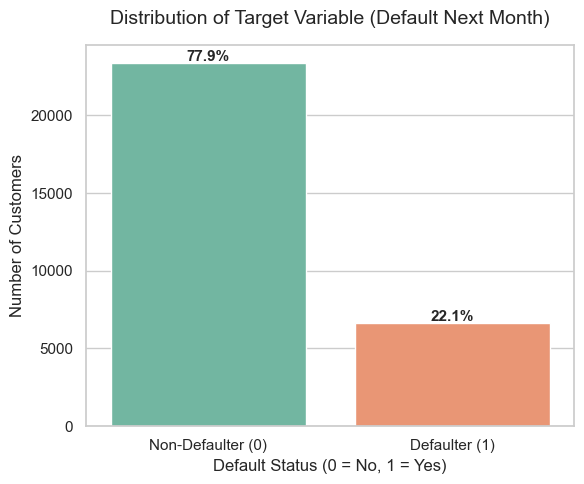

In [ ]:
# Default වෙන සහ නොවෙන අයගේ ගණන සෙවීම
default_counts = df['default_next_month'].value_counts()
default_percentages = df['default_next_month'].value_counts(normalize=True) * 100

print("--- Class Distribution ---")
print(f"Non-Defaulters (0): {default_counts[0]} ({default_percentages[0]:.2f}%)")
print(f"Defaulters (1): {default_counts[1]} ({default_percentages[1]:.2f}%)\n")

plt.figure(figsize=(6, 5))
ax = sns.countplot(x='default_next_month', hue='default_next_month', data=df, palette='Set2', legend=False)
plt.title('Distribution of Target Variable (Default Next Month)', fontsize=14, pad=15)
plt.xlabel('Default Status (0 = No, 1 = Yes)', fontsize=12)
plt.ylabel('Number of Customers', fontsize=12)
plt.xticks([0, 1], ['Non-Defaulter (0)', 'Defaulter (1)'])

for p in ax.patches:
    percentage = f'{100 * p.get_height() / len(df):.1f}%'
    x_pos = p.get_x() + p.get_width() / 2
    y_pos = p.get_height() + 100
    ax.annotate(percentage, (x_pos, y_pos), ha='center', fontsize=11, weight='bold')

plt.tight_layout()
plt.show()

### 📊 Step 2: Demographic Analysis vs Default Risk
In this step, we analyze how customer demographics such as Gender and Education Level correlate with the default rates. This helps FinTrust Digital Finance understand which customer segments carry higher financial risk.

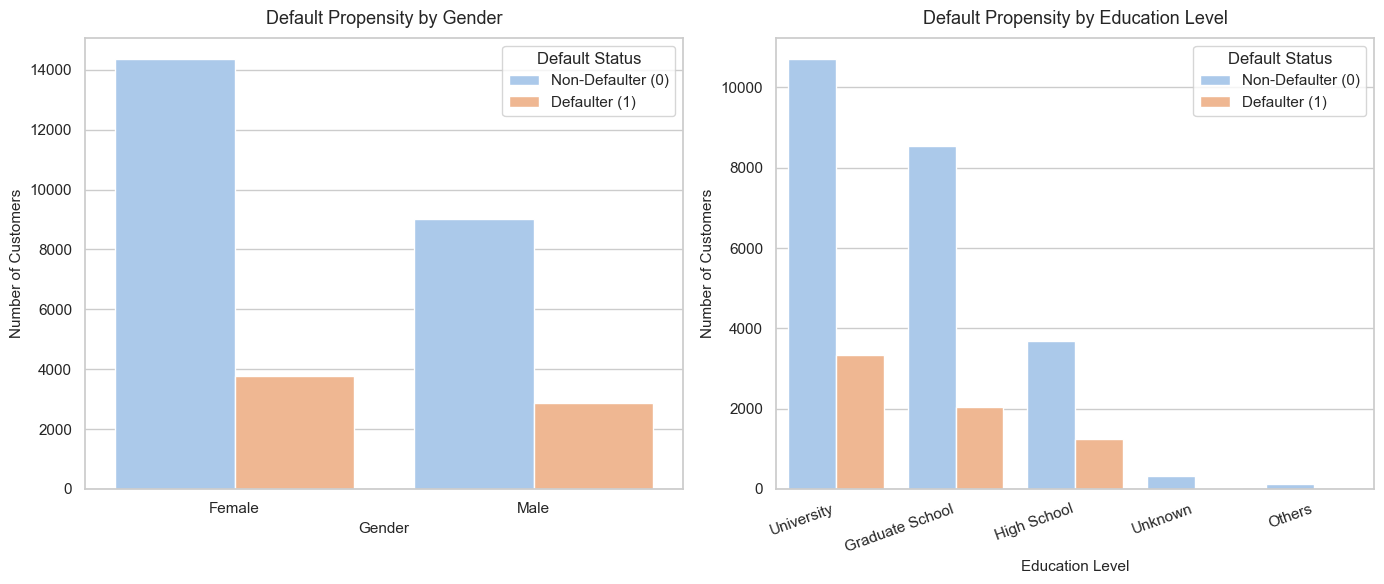

In [ ]:
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
sns.countplot(x='gender', hue='default_next_month', data=df, palette='pastel')
plt.title('Default Propensity by Gender', fontsize=13, pad=10)
plt.xlabel('Gender', fontsize=11)
plt.ylabel('Number of Customers', fontsize=11)
plt.legend(title='Default Status', labels=['Non-Defaulter (0)', 'Defaulter (1)'])

plt.subplot(1, 2, 2)
sns.countplot(x='education', hue='default_next_month', data=df, palette='pastel')
plt.title('Default Propensity by Education Level', fontsize=13, pad=10)
plt.xlabel('Education Level', fontsize=11)
plt.ylabel('Number of Customers', fontsize=11)
plt.xticks(rotation=20, ha='right') 
plt.legend(title='Default Status', labels=['Non-Defaulter (0)', 'Defaulter (1)'])

plt.tight_layout()
plt.show()

### 📊 Step 3: Correlation Matrix and Insights
To understand the linear relationships between numeric financial metrics (such as credit limits, bill amounts, and repayment amounts) and the target risk variable, we construct a Correlation Heatmap. This helps identify structural patterns and multi-collinearity issues prior to training our predictive models.

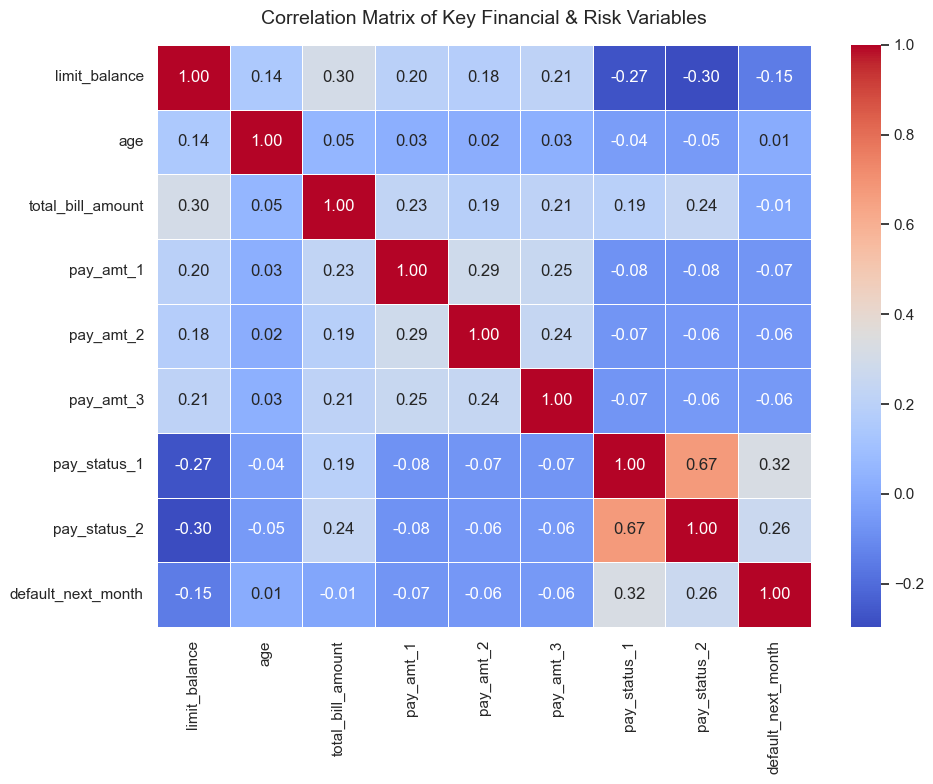

In [ ]:
correlation_cols = [
    'limit_balance', 'age', 'total_bill_amount', 
    'pay_amt_1', 'pay_amt_2', 'pay_amt_3', 
    'pay_status_1', 'pay_status_2', 'default_next_month'
]

corr_matrix = df[correlation_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Matrix of Key Financial & Risk Variables', fontsize=14, pad=15)

plt.tight_layout()
plt.show()